<a href="https://colab.research.google.com/github/hanayanita/machine_learning/blob/main/Return_Abuse_Detection_and_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **MAIC01802 – AI for IT Professionals**

**Assessment 2: Applied AI Solution Design**

# **An AI-Integrated System for E-Commerce Return Abuse Detection and Classification**

========================================================================================================

##SYSTEM SETUP: IMPORT LIBRARY, AUTHENTICATE, AND DOWNLOAD DATASET

In [ ]:
# CELL 1: IMPORT LIBRARY, AUTHENTICATE, AND DOWNLOAD DATASET
# ============================================================

# --- IMPORTANT ----------------------------------------------
# Before starting the system, setup
# GEMINI_API_KEY and KAGGLE_API_TOKEN in Google Colab Secrets
# Use KAGGLE_API_TOKEN with this format {"username":"username","key":"token"}
# and grant the access to this notebook
# ------------------------------------------------------------

# Import library
!pip install transformers pandas
!pip install kagglehub
!pip install kaggle -q
!pip install google-generativeai

# !pip install shap gradio xgboost --quiet
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import requests
import joblib
import time
from google import genai
from google.colab import userdata
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    f1_score,
    accuracy_score)
import shap
import gradio as gr

%matplotlib inline
plt.rcParams['figure.dpi'] = 150
print("All libraries loaded successfully.")

# Initialize the gemini client
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
client = genai.Client(api_key=GEMINI_API_KEY)

# Authenticate to kaggle using api token
# Load the token from secretsYy
kaggle_token = userdata.get('KAGGLE_API_TOKEN')

# Write it to the expected config location
os.makedirs('/root/.config/kaggle', exist_ok=True)
with open('/root/.config/kaggle/kaggle.json', 'w') as f:
    f.write(kaggle_token)
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)
print("Kaggle authenticated!")

# Downloading the dataset from Kaggle
!kaggle datasets download -d sarveshchhetri/e-commerce-return-abuse-detection-dataset
!unzip e-commerce-return-abuse-detection-dataset.zip -d dataset


All libraries loaded successfully.
Kaggle authenticated!
Dataset URL: https://www.kaggle.com/datasets/sarveshchhetri/e-commerce-return-abuse-detection-dataset
License(s): apache-2.0
100% 2.72M/2.72M [00:01<00:00, 2.39MB/s]

Archive:  e-commerce-return-abuse-detection-dataset.zip
  inflating: dataset/ecommerce_return_abuse_dataset.csv  


# **STAGE 1: PREPROCESSING & FEATURE ENGINEERING**

### LOAD DATA & QUALITY CHECK

In [ ]:
# CELL 2: LOAD DATA & QUALITY CHECK
# ============================================================

df = pd.read_csv('dataset/ecommerce_return_abuse_dataset.csv')

print("=" * 55)
print("SHAPE")
print("=" * 55)
print(df.shape)

print("\n" + "=" * 55)
print("TARGET DISTRIBUTION")
print("=" * 55)
print(df['abuse_type'].value_counts())
print()
print(df['abuse_type'].value_counts(normalize=True).round(3))

print("\n" + "=" * 55)
print("MISSING VALUES")
print("=" * 55)
missing = df.isnull().sum()
print("None — dataset is complete."
      if missing.sum() == 0
      else missing[missing > 0])

print("\n" + "=" * 55)
print("LEAKAGE CHECK — abuse_label vs abuse_type")
print("=" * 55)
print(pd.crosstab(df['abuse_type'], df['abuse_label']))
print("\n→ abuse_label is a direct numeric encoding of")
print("  abuse_type. Confirmed leakage — dropped before")
print("  any modelling.")

SHAPE
(60000, 35)

TARGET DISTRIBUTION
abuse_type
Legitimate           42060
Policy Abuser         7192
Fraudulent Return     6112
Wardrobing            4636
Name: count, dtype: int64

abuse_type
Legitimate           0.701
Policy Abuser        0.120
Fraudulent Return    0.102
Wardrobing           0.077
Name: proportion, dtype: float64

MISSING VALUES
None — dataset is complete.

LEAKAGE CHECK — abuse_label vs abuse_type
abuse_label            0     1     2     3
abuse_type                                
Fraudulent Return      0     0  6112     0
Legitimate         42060     0     0     0
Policy Abuser          0  7192     0     0
Wardrobing             0     0     0  4636

→ abuse_label is a direct numeric encoding of
  abuse_type. Confirmed leakage — dropped before
  any modelling.


### EXPLORATORY DATA ANALYSIS (EDA)

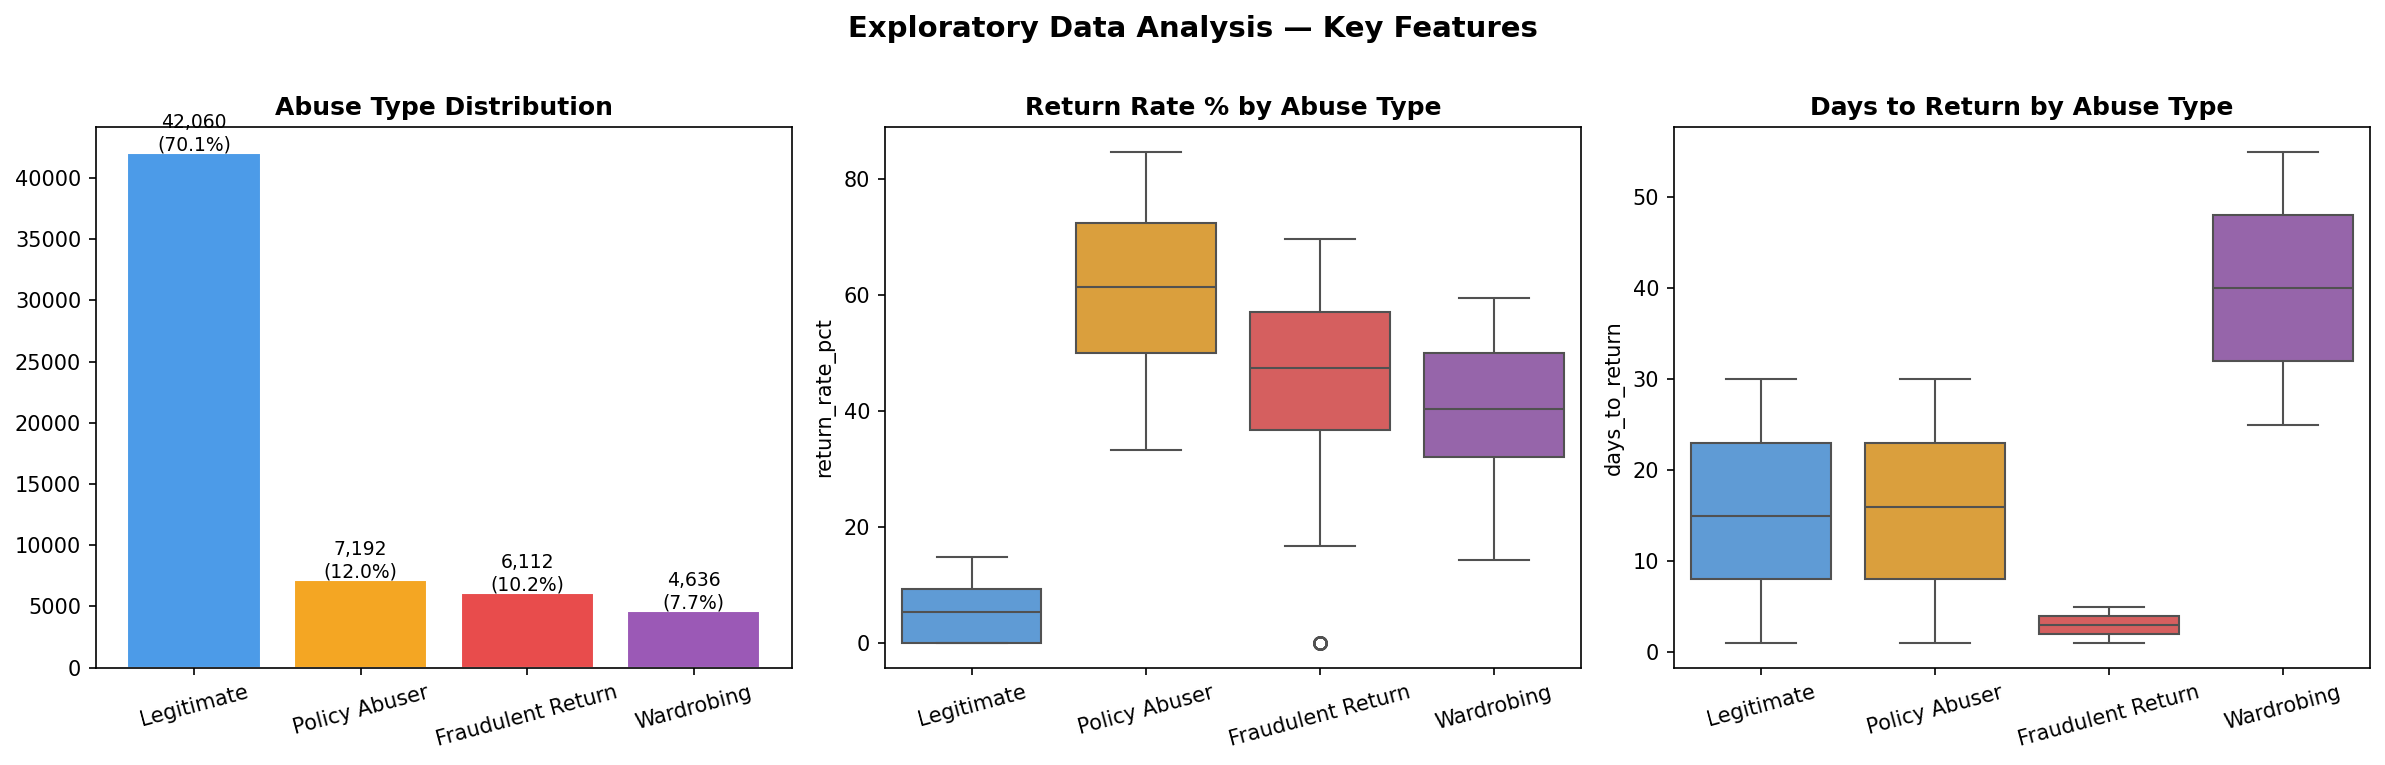

Saved: eda_main.png


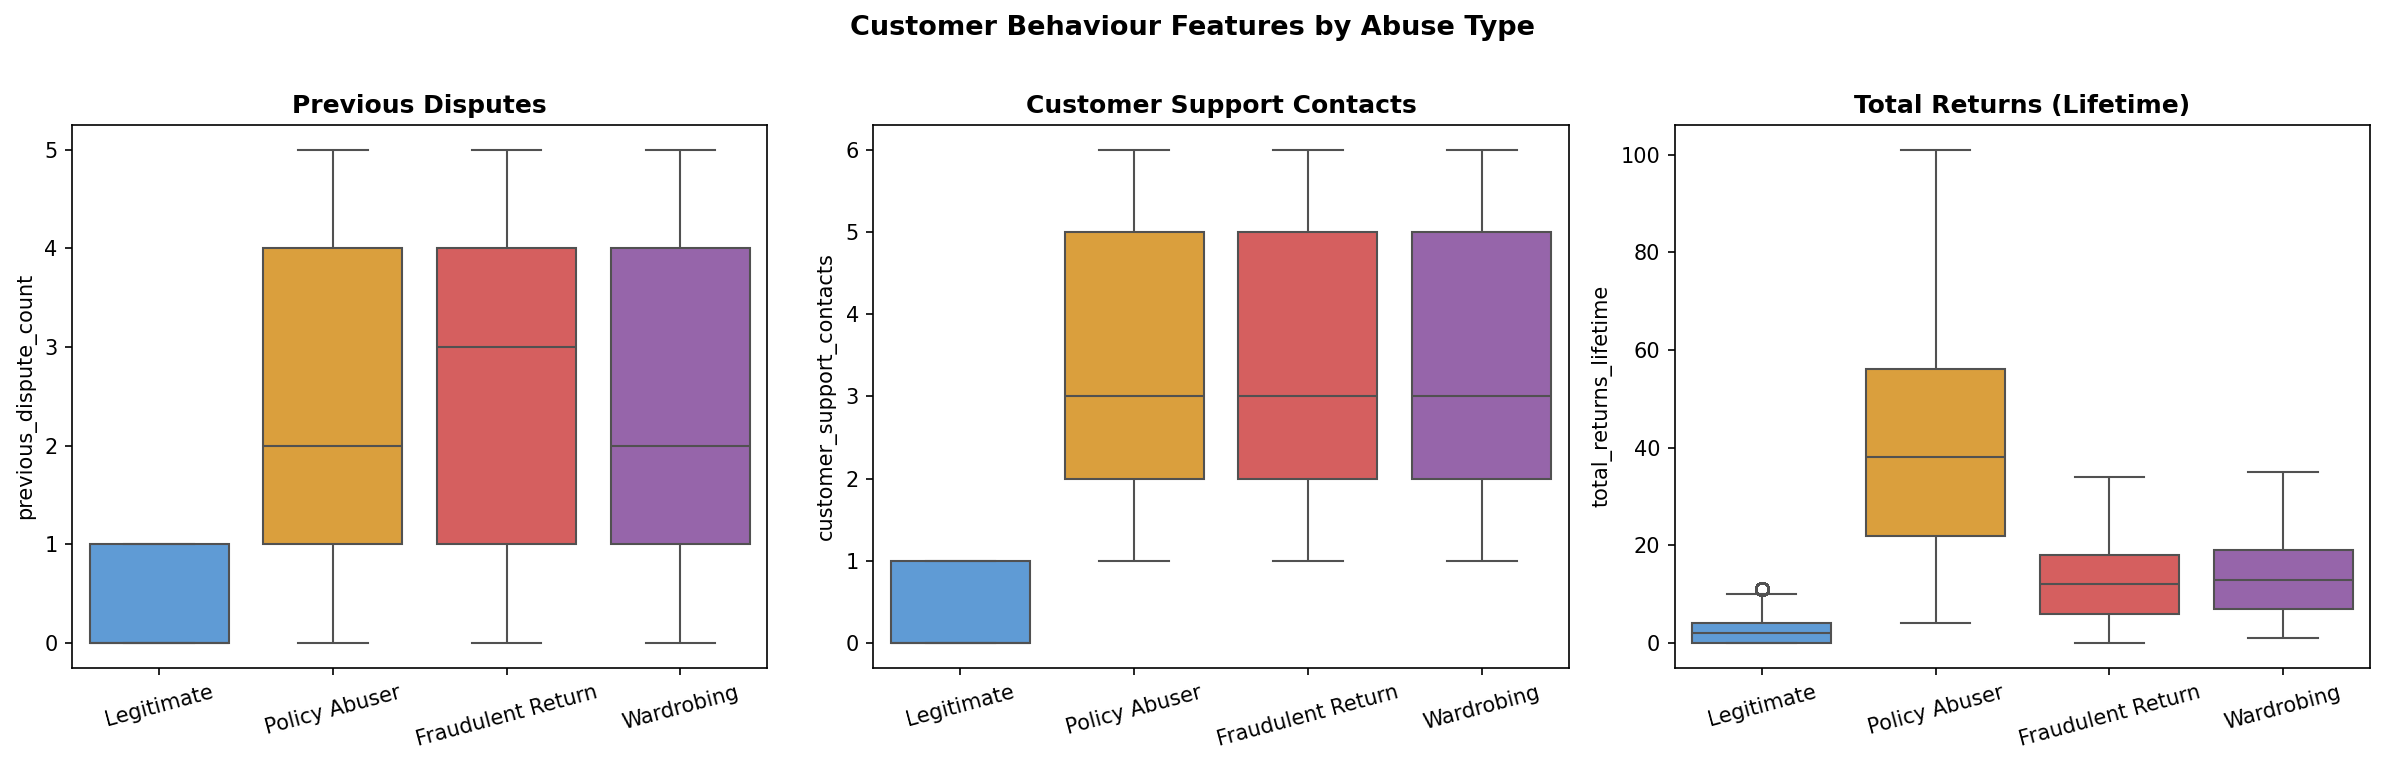

Saved: eda_behaviour.png


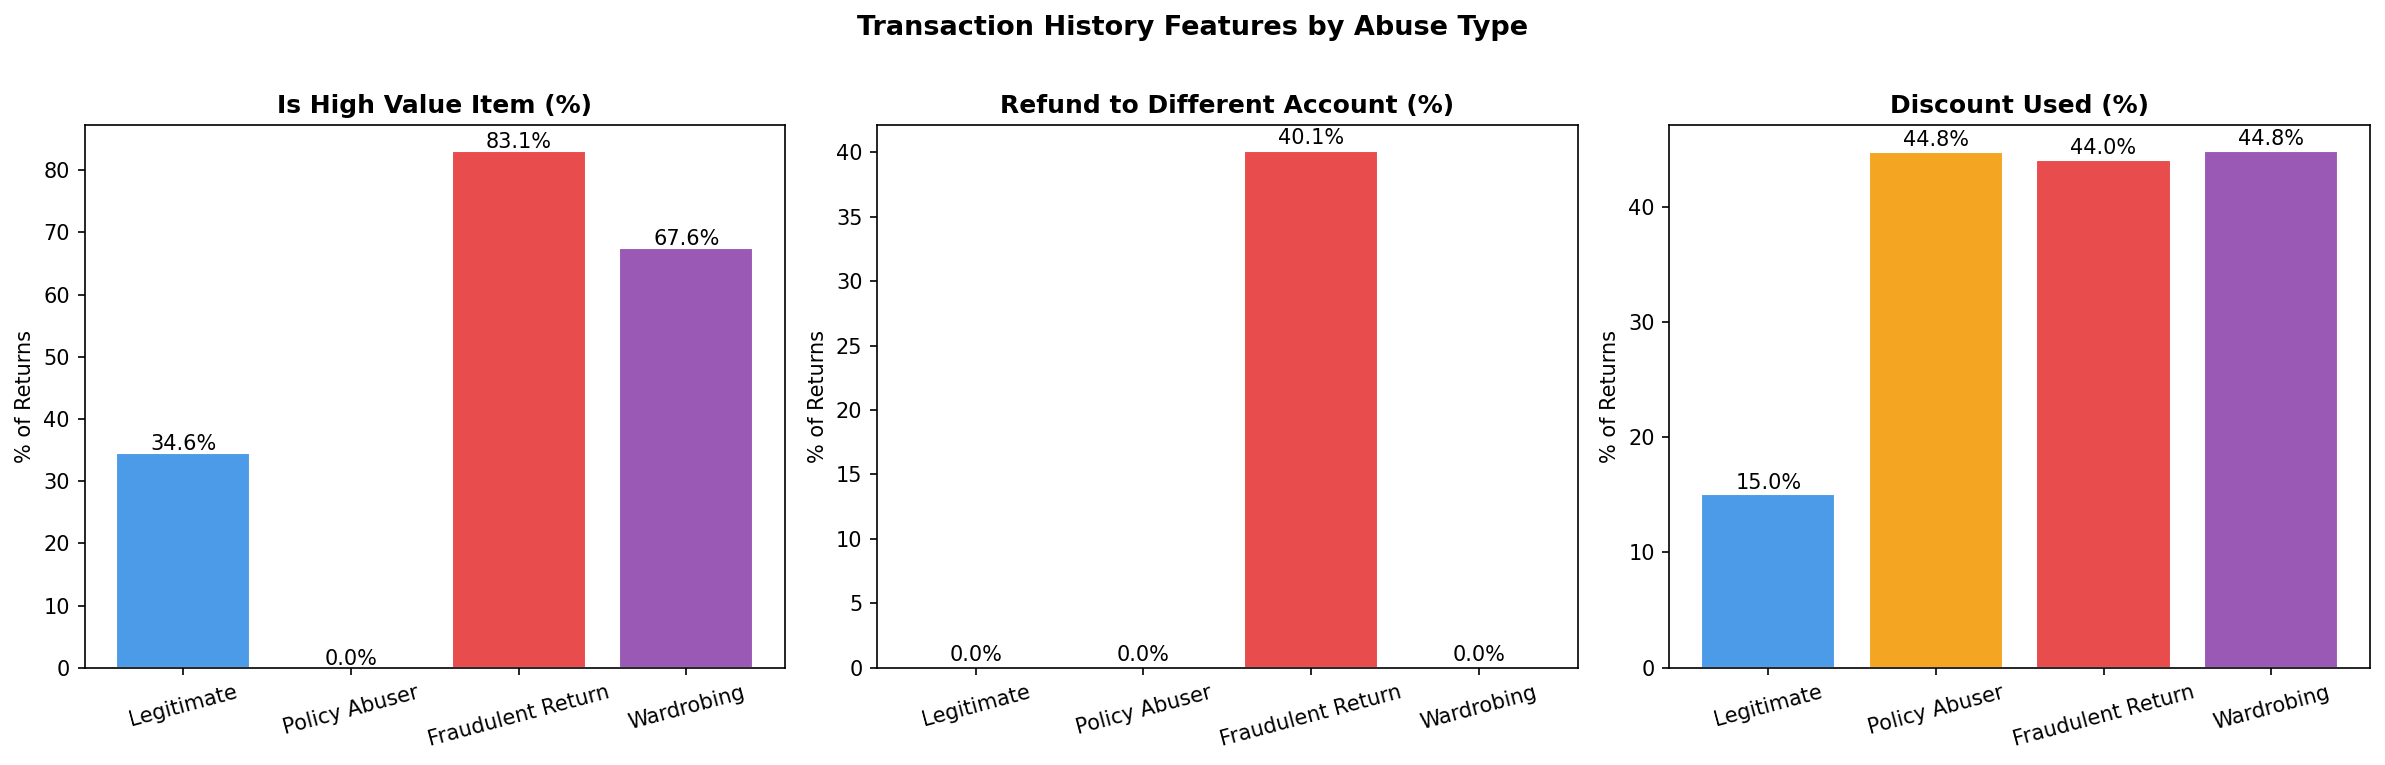

Saved: eda_transaction.png


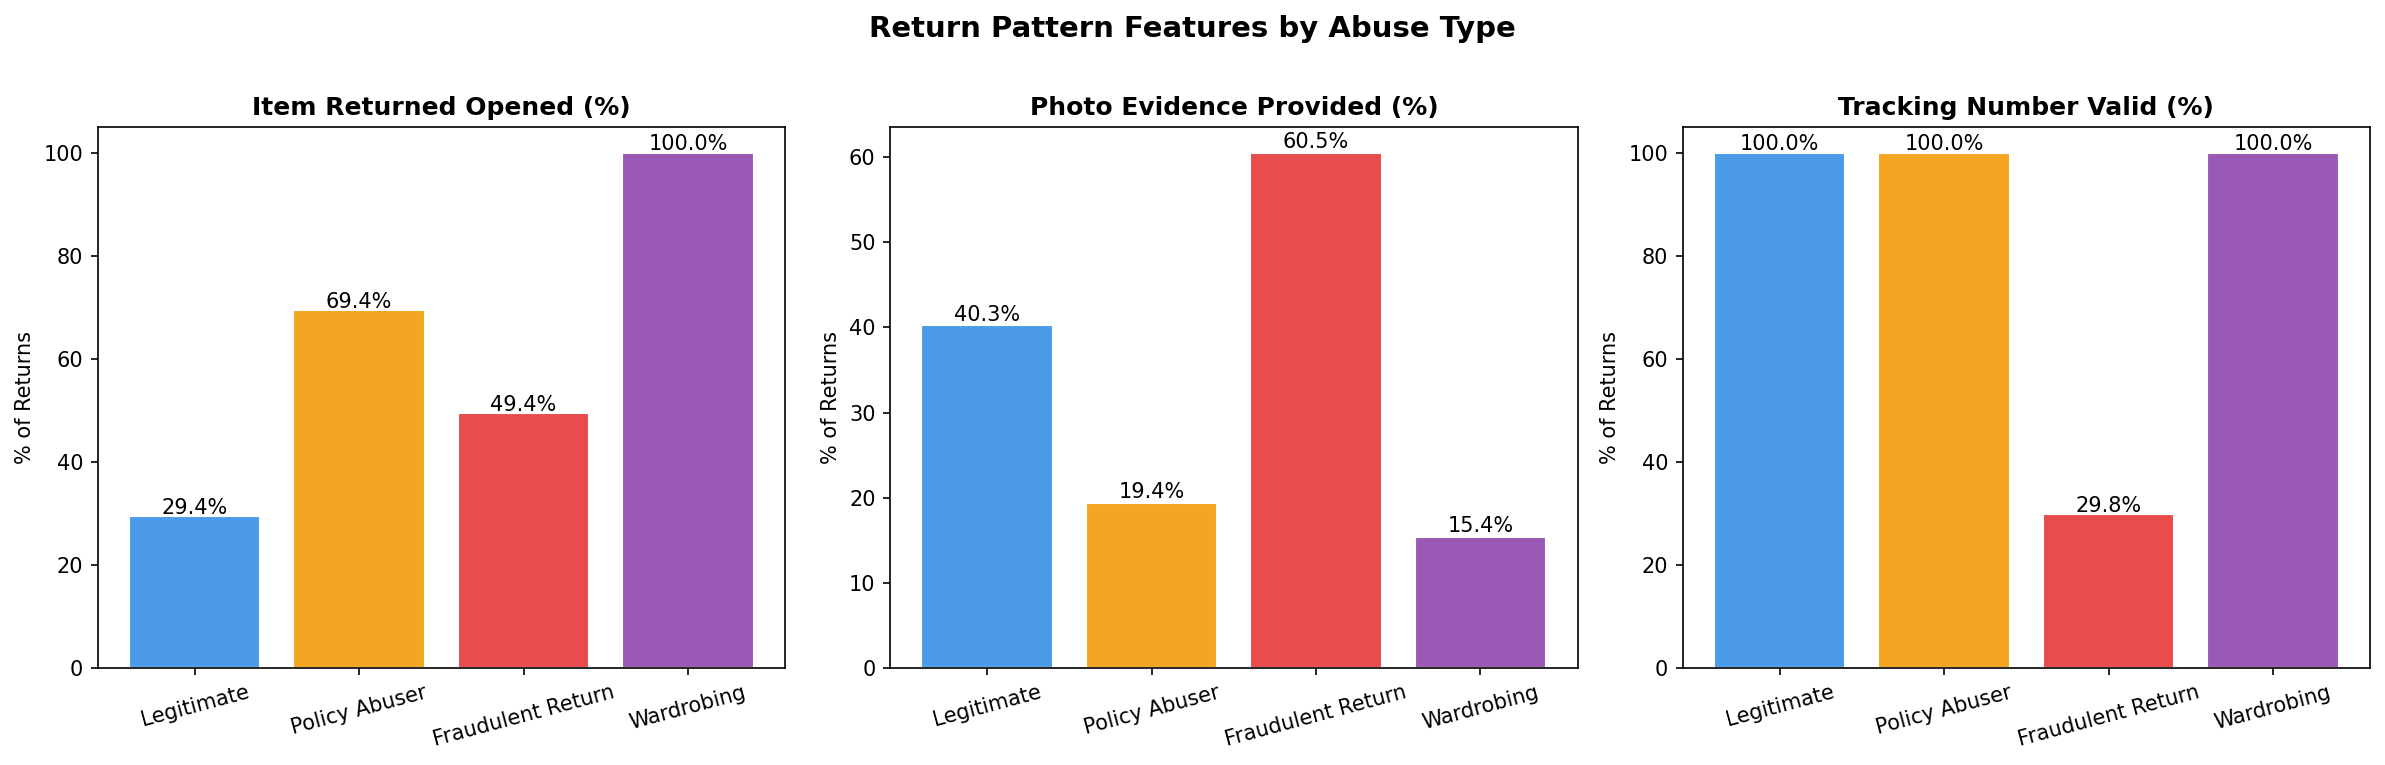

Saved: eda_return_patterns.png


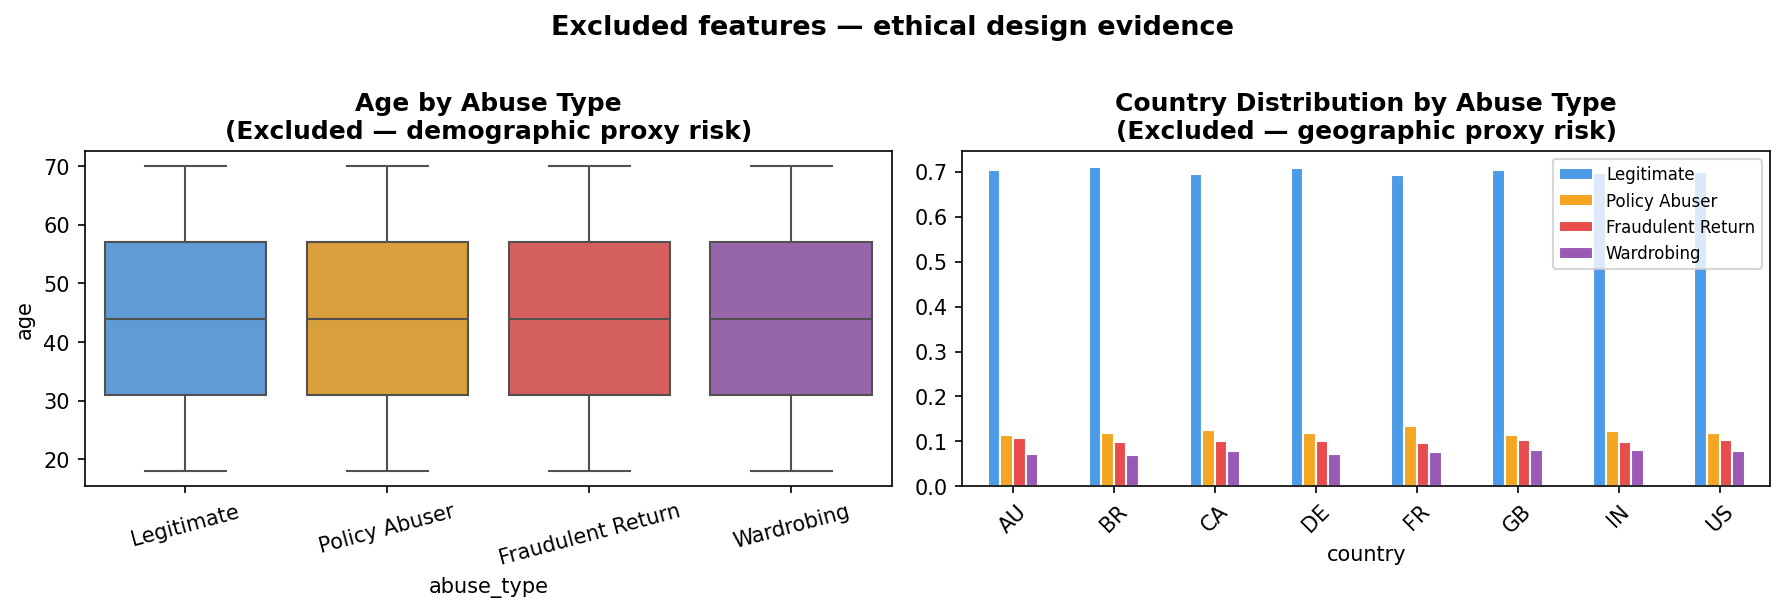

Saved: eda_excluded_features.png


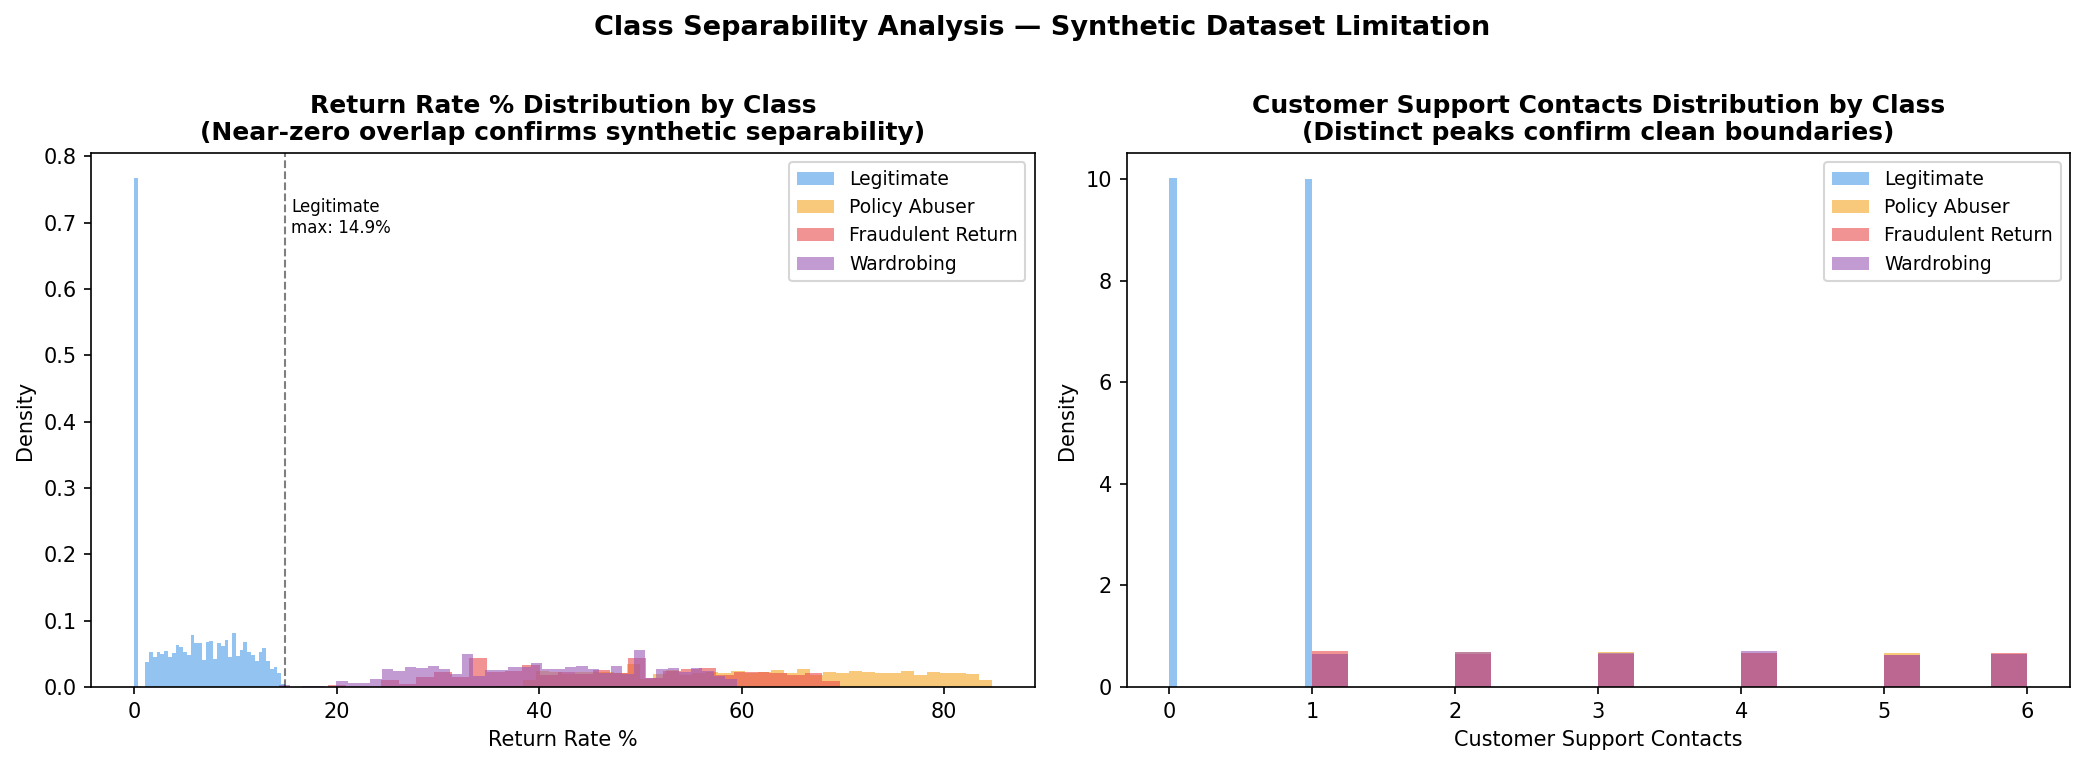

Saved: eda_separability.png

Return rate separability evidence:
                    min   max   mean
abuse_type                          
Fraudulent Return   0.0  69.7  47.05
Legitimate          0.0  14.9   5.44
Policy Abuser      33.3  84.7  61.23
Wardrobing         14.3  59.5  40.46

Gap between Legitimate max and nearest abuse min:
Legitimate max:    14.9%
Wardrobing min:    14.3%
Gap:               -0.6 percentage points
→ No overlap between Legitimate and any abuse class


In [ ]:
# CELL 3: EXPLORATORY DATA ANALYSIS
# ============================================================

abuse_order = ['Legitimate', 'Policy Abuser',
               'Fraudulent Return', 'Wardrobing']
colors      = ['#4C9BE8', '#F4A623', '#E84C4C', '#9B59B6']
palette     = dict(zip(abuse_order, colors))

# === Plot A: Class distribution + Top Features ==============
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Class distribution
counts = df['abuse_type'].value_counts().reindex(abuse_order)
bars = axes[0].bar(counts.index, counts.values,
                   color=colors, edgecolor='white')
axes[0].set_title('Abuse Type Distribution',
                  fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{val:,}\n({val/len(df)*100:.1f}%)',
        ha='center', fontsize=9)

# Return rate by abuse type
sns.boxplot(data=df, x='abuse_type', y='return_rate_pct',
            order=abuse_order, palette=palette, ax=axes[1])
axes[1].set_title('Return Rate % by Abuse Type',
                  fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

# Days to return by abuse type
sns.boxplot(data=df, x='abuse_type', y='days_to_return',
            order=abuse_order, palette=palette, ax=axes[2])
axes[2].set_title('Days to Return by Abuse Type',
                  fontweight='bold')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Exploratory Data Analysis — Key Features',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_main.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_main.png")

# === Plot B: Customer behavior features ========================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

behaviour_features = [
    ('previous_dispute_count',    'Previous Disputes'),
    ('customer_support_contacts', 'Customer Support Contacts'),
    ('total_returns_lifetime',    'Total Returns (Lifetime)'),
]

for ax, (col, label) in zip(axes.flatten(), behaviour_features):
    sns.boxplot(data=df, x='abuse_type', y=col,
                order=abuse_order, palette=palette, ax=ax)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Customer Behaviour Features by Abuse Type',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_behaviour.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_behaviour.png")

# === Plot C: Transaction History features ========================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

binary_features = [
    ('is_high_value_item',          'Is High Value Item (%)'),
    ('refund_to_different_account', 'Refund to Different Account (%)'),
    ('discount_used',               'Discount Used (%)'),
]

for ax, (col, label) in zip(axes, binary_features):
    pct  = df.groupby('abuse_type')[col].mean() * 100
    pct  = pct.reindex(abuse_order)
    bars = ax.bar(pct.index, pct.values,
                  color=colors, edgecolor='white')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('% of Returns')
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, pct.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=10)

plt.suptitle('Transaction History Features by Abuse Type',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_transaction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_transaction.png")

# === Plot D: Return pattern features ========================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pattern_cols = [
    ('item_returned_opened',   'Item Returned Opened (%)'),
    ('photo_evidence_provided','Photo Evidence Provided (%)'),
    ('tracking_number_valid',  'Tracking Number Valid (%)'),
]
for ax, (col, label) in zip(axes, pattern_cols):
    pct  = df.groupby('abuse_type')[col].mean() * 100
    pct  = pct.reindex(abuse_order)
    bars = ax.bar(pct.index, pct.values,
                  color=colors, edgecolor='white')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('% of Returns')
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, pct.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=10)

plt.suptitle('Return Pattern Features by Abuse Type',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_return_patterns.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_return_patterns.png")

# === Plot E: Excluded features — ethical design evidence =====
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plt.suptitle('Excluded features — ethical design evidence',
    fontsize=13, fontweight='bold', y=1.01)

# Plot 1: Age by Abuse Type Plot
sns.boxplot(data=df, x='abuse_type', y='age',
            order=abuse_order, palette=palette, ax=axes[0])
axes[0].set_title(
    'Age by Abuse Type\n(Excluded — demographic proxy risk)',
    fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# plot 2: Country Distribution by Abuse Type Plot
country_pcts = (
    df.groupby(['country', 'abuse_type'])
    .size().unstack().fillna(0)
    .pipe(lambda d: d.div(d.sum(axis=1), axis=0))
    .reindex(columns=abuse_order))

country_pcts.plot(kind='bar', ax=axes[1],
                  color=colors, edgecolor='white')
axes[1].set_title(
    'Country Distribution by Abuse Type\n'
    '(Excluded — geographic proxy risk)',
    fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_excluded_features.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_excluded_features.png")

# === Plot F: Data separability evidence =====
# Shows why near-perfect metrics reflect synthetic data
# characteristics rather than model sophistication

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: return_rate_pct distribution — clearest separability
# KDE plot shows overlap between classes
for i, (abuse, color) in enumerate(zip(abuse_order, colors)):
    subset = df[df['abuse_type'] == abuse]['return_rate_pct']
    axes[0].hist(subset, bins=40, alpha=0.6,
                color=color, label=abuse, density=True)
axes[0].set_xlabel('Return Rate %')
axes[0].set_ylabel('Density')
axes[0].set_title('Return Rate % Distribution by Class\n'
                  '(Near-zero overlap confirms synthetic separability)',
                  fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].axvline(14.9, color='black', linestyle='--',
                linewidth=1, alpha=0.5)
axes[0].text(15.5, axes[0].get_ylim()[1]*0.85,
             'Legitimate\nmax: 14.9%',
             fontsize=8, color='black')

# Plot 2: customer_support_contacts
for abuse, color in zip(abuse_order, colors):
    subset = df[df['abuse_type'] == abuse][
        'customer_support_contacts']
    axes[1].hist(subset, bins=20, alpha=0.6,
                color=color, label=abuse, density=True)
axes[1].set_xlabel('Customer Support Contacts')
axes[1].set_ylabel('Density')
axes[1].set_title('Customer Support Contacts Distribution by Class\n'
                  '(Distinct peaks confirm clean boundaries)',
                  fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle(
    'Class Separability Analysis — Synthetic Dataset Limitation',
    fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_separability.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_separability.png")

# Print the exact numbers that prove separability
print("\nReturn rate separability evidence:")
print(df.groupby('abuse_type')['return_rate_pct'].agg(
    ['min','max','mean']).round(2))
print("\nGap between Legitimate max and nearest abuse min:")
legit_max = df[df['abuse_type']=='Legitimate'][
    'return_rate_pct'].max()
wardrobing_min = df[df['abuse_type']=='Wardrobing'][
    'return_rate_pct'].min()
print(f"Legitimate max:    {legit_max:.1f}%")
print(f"Wardrobing min:    {wardrobing_min:.1f}%")
print(f"Gap:               {wardrobing_min - legit_max:.1f} percentage points")
print(f"→ No overlap between Legitimate and any abuse class")


### PREPROCESSING & FEATURE ENGINEERING

In [ ]:
# CELL 4: PREPROCESSING & FEATURE ENGINEERING
# ============================================================

df_m = df.copy()

# ========Implementation of Data Strategy (Section 2.3)=======

# --- 1. abuse_label dropped — direct leakage ----------------
#    Confirmed: crosstab shows 1:1 mapping with abuse_type.
df_m.drop(columns=[
    'order_id', 'customer_id', 'abuse_label'
], inplace=True)

# --- 2. Feature engineering ---------------------------------
# Engineer: refund-to-order ratio (Group B feature)
df_m['refund_to_order_ratio'] = (
    df_m['refund_amount_requested_usd'] /
    df_m['avg_order_value_usd'].replace(0, np.nan)
).fillna(0).round(4)

# --- 3. Feature selection -----------------------------------
# Drop demographic, geographic, and out-of-RQ-scope columns
df_m.drop(columns=[
    'age', 'country',
    'platform', 'device_type', 'shipping_carrier',
    'wishlist_to_cart_time_hrs',
    'review_left_after_return',
    'address_change_before_delivery',
    'product_category',
    'order_date', 'return_date'
], inplace=True)

# Final RQ-aligned feature set — 21 features
# Three groups aligned to Research Question:
# customer behaviour, transaction history, return patterns
FEATURES = [
    # Group A: Customer Behaviour (8)
    'return_rate_pct',
    'total_returns_lifetime',
    'total_orders_lifetime',
    'previous_dispute_count',
    'customer_support_contacts',
    'account_age_days',
    'customer_segment',
    'multiple_accounts_flag',

    # Group B: Transaction History (7)
    'avg_order_value_usd',
    'refund_amount_requested_usd',
    'payment_method',
    'is_high_value_item',
    'discount_used',
    'refund_to_different_account',
    'refund_to_order_ratio',

    # Group C: Return Patterns (6)
    'days_to_return',
    'item_returned_opened',
    'return_packaging_intact',
    'photo_evidence_provided',
    'tracking_number_valid',
    'return_reason',
]
X = df_m[FEATURES].copy()

# --- 4. Encoding ------------------------------------------
# Encode categorical columns
# Save encoders — required for Gradio inference
le_dict = {}
for col in ['customer_segment', 'payment_method',
            'return_reason']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le
# -----------------------------------------------------------

# Define target — multiclass only
# Binary stage removed
TARGET_MAP = {
    'Legitimate':        0,
    'Policy Abuser':     1,
    'Fraudulent Return': 2,
    'Wardrobing':        3,
}
INV_MAP     = {v: k for k, v in TARGET_MAP.items()}
CLASS_NAMES = list(TARGET_MAP.keys())
FEATURE_NAMES = X.columns.tolist()
# Define abuse_type as a target column
y = df_m['abuse_type'].map(TARGET_MAP)

print(f"Final feature count: {len(FEATURE_NAMES)}")
print(f"Features: {FEATURE_NAMES}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))

# --- 5. Train-test split 80/20 -----------------------------
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42)

print(f"Training set: {X_tr.shape}")
print(f"Test set:     {X_te.shape}")
print(f"\nTraining distribution:")
print(y_tr.value_counts())

Final feature count: 21
Features: ['return_rate_pct', 'total_returns_lifetime', 'total_orders_lifetime', 'previous_dispute_count', 'customer_support_contacts', 'account_age_days', 'customer_segment', 'multiple_accounts_flag', 'avg_order_value_usd', 'refund_amount_requested_usd', 'payment_method', 'is_high_value_item', 'discount_used', 'refund_to_different_account', 'refund_to_order_ratio', 'days_to_return', 'item_returned_opened', 'return_packaging_intact', 'photo_evidence_provided', 'tracking_number_valid', 'return_reason']

Target distribution:
abuse_type
0    42060
1     7192
2     6112
3     4636
Name: count, dtype: int64
abuse_type
0    0.701
1    0.120
2    0.102
3    0.077
Name: proportion, dtype: float64
Training set: (48000, 21)
Test set:     (12000, 21)

Training distribution:
abuse_type
0    33648
1     5753
2     4890
3     3709
Name: count, dtype: int64


# **STAGE 2: MULTICLASS CLASSIFICATION (SUPERVISED ML)**

In [ ]:
# CELL 5: MODEL TRAINING
# ============================================================

# --- XGBoost — PRIMARY MODEL --------------------------------
xgb = XGBClassifier(
    n_estimators=100,         # modified from 200 to 100
    learning_rate=0.05,       # learning speed
    max_depth=4,              # modified from 5 to 4
    subsample=0.8,            # use 80% of training rows per tree
    colsample_bytree=0.8,     # use 80% of features per tree
    objective='multi:softprob', # multiclass classification with probabilities
    num_class=4,              # four return abuse classes
    eval_metric='mlogloss',   # multiclass log loss evaluation
    random_state=42,          # reproducible results
    verbosity=0               # suppress training output
)

xgb.fit(X_tr, y_tr)
print("\nXGBoost trained.")

# -- Random Forest — COMPARISON MODEL -------------------------
# Purpose: empirical model comparison in Section 4
# and consensus signal in Stage 4 routing
rf = RandomForestClassifier(
    n_estimators=100,        # number of trees
    class_weight='balanced', # adjust for class imbalance
    random_state=42          # reproducibility
)
rf.fit(X_tr, y_tr)
print("Random Forest trained.")


XGBoost trained.
Random Forest trained.


# **STAGE 3: EVALUATION AND INTERPRETABILITY**

### EVALUATION

XGBoost — PRIMARY MODEL
                   precision    recall  f1-score   support

       Legitimate       1.00      1.00      1.00      8412
    Policy Abuser       0.98      0.99      0.99      1439
Fraudulent Return       1.00      0.99      0.99      1222
       Wardrobing       0.99      0.99      0.99       927

         accuracy                           1.00     12000
        macro avg       0.99      0.99      0.99     12000
     weighted avg       1.00      1.00      1.00     12000

ROC-AUC (OvR macro): 1.0000

Random Forest — COMPARISON MODEL
                   precision    recall  f1-score   support

       Legitimate       1.00      1.00      1.00      8412
    Policy Abuser       0.99      0.99      0.99      1439
Fraudulent Return       1.00      0.99      1.00      1222
       Wardrobing       0.99      0.99      0.99       927

         accuracy                           1.00     12000
        macro avg       0.99      0.99      0.99     12000
     weighted avg       

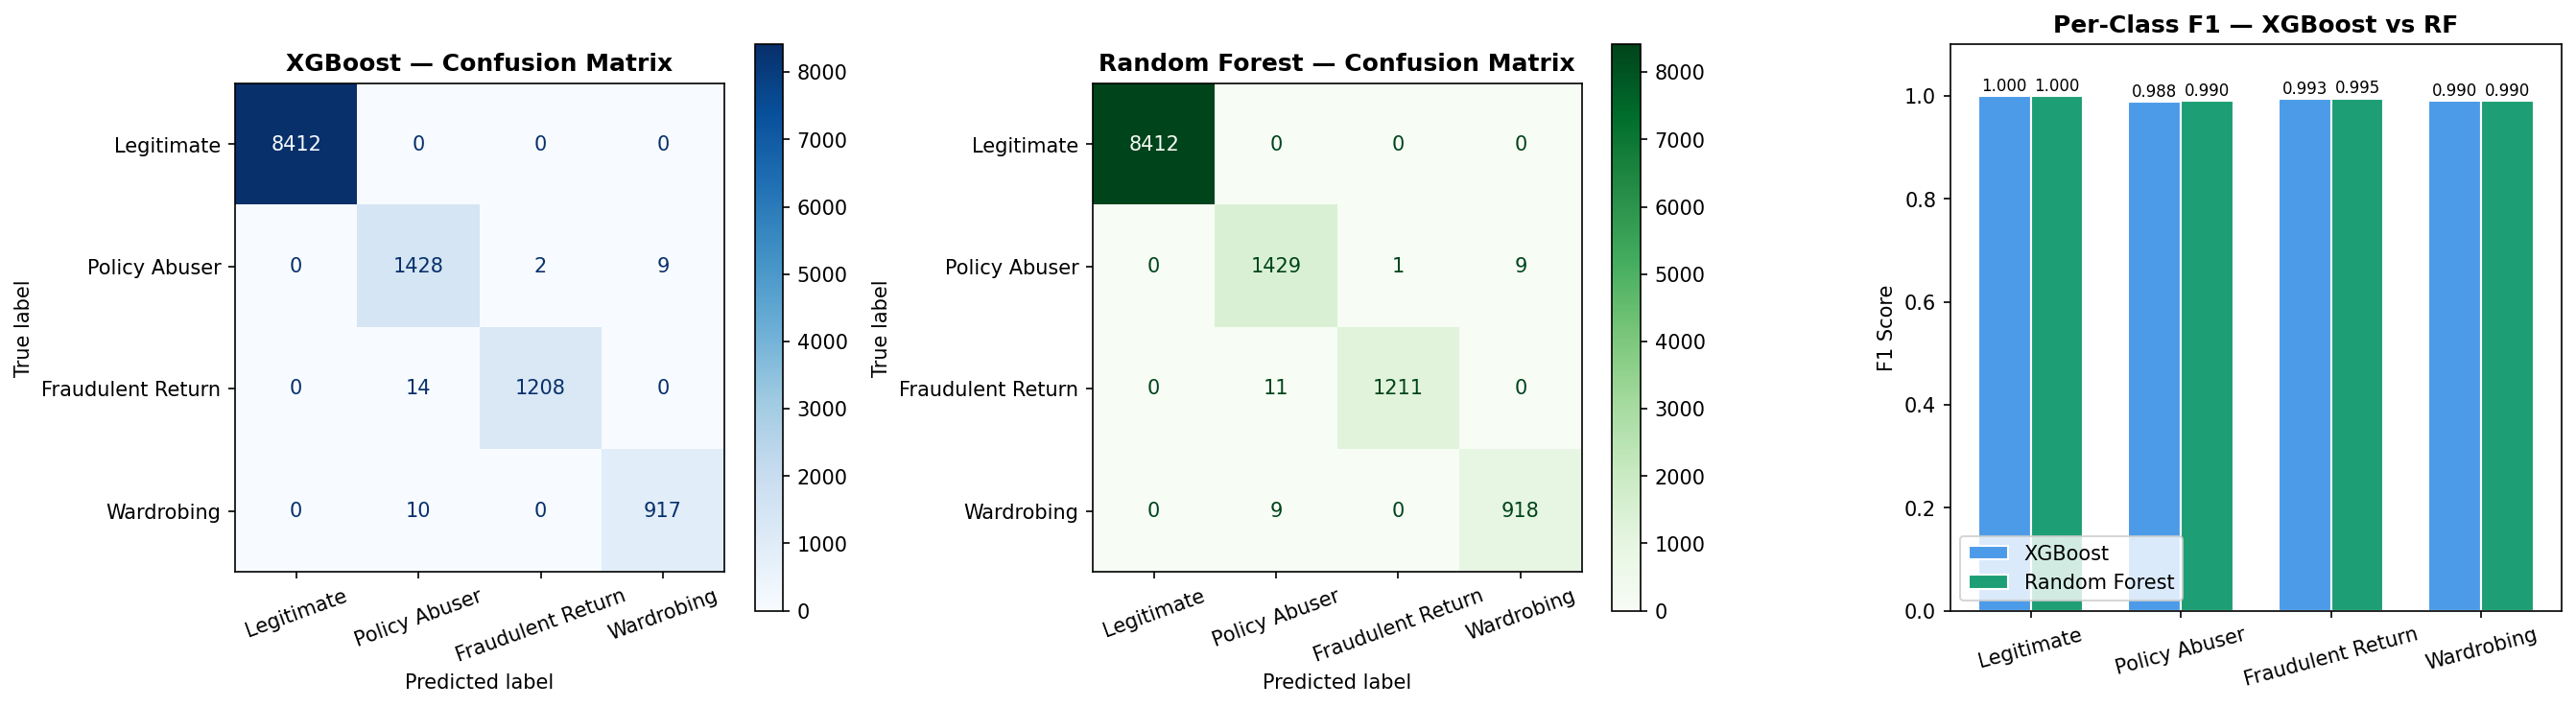

Saved: evaluation.png

XGBoost prediction confidence distribution:
count    12000.000
mean         0.989
std          0.039
min          0.399
25%          0.991
50%          0.998
75%          0.998
max          0.998
dtype: float64
Above 0.95 confidence: 97.5%
Below 0.70 confidence: 0.7%

Note: Near-perfect confidence reflects synthetic
dataset's artificially clean class boundaries.
See Section 4 limitations for full discussion.


In [ ]:
# ============================================================
# CELL 6: EVALUATION
# ============================================================

# Predictions
y_pred_xgb = xgb.predict(X_te)
y_pred_rf  = rf.predict(X_te)
y_prob_xgb = xgb.predict_proba(X_te)
y_prob_rf  = rf.predict_proba(X_te)

# --- Classification reports ---------------------------------
print("=" * 60)
print("XGBoost — PRIMARY MODEL")
print("=" * 60)
print(classification_report(
    y_te, y_pred_xgb,
    target_names=CLASS_NAMES))
roc_xgb = roc_auc_score(
    y_te, y_prob_xgb, multi_class='ovr', average='macro')
print(f"ROC-AUC (OvR macro): {roc_xgb:.4f}")

print("\n" + "=" * 60)
print("Random Forest — COMPARISON MODEL")
print("=" * 60)
print(classification_report(
    y_te, y_pred_rf,
    target_names=CLASS_NAMES))
roc_rf = roc_auc_score(
    y_te, y_prob_rf, multi_class='ovr', average='macro')
print(f"ROC-AUC (OvR macro): {roc_rf:.4f}")
# Macro treats all classes equally.
# ROC-AUC (OvR macro) tells how well the model separates each abuse category from the others.

# --- Model comparison table ----------------------------------
# Macro F1 calculates the F1-score for each class separately and then takes the average.
# Weighted F1 also calculates F1 per class, but each class is weighted by its number of samples.

# Majority class baseline — predicts Legitimate always
# Proves model learned beyond trivial class frequency
baseline_acc      = y_te.value_counts(normalize=True).max()
baseline_f1_macro = f1_score(
    y_te,
    np.full(len(y_te), y_te.mode()[0]),  # always predict majority
    average='macro',
    zero_division=0)
baseline_f1_w = f1_score(
    y_te,
    np.full(len(y_te), y_te.mode()[0]),
    average='weighted',
    zero_division=0)

comparison = pd.DataFrame({
    'Model': [
        'XGBoost (primary)',
        'Random Forest (comparison)',
        'Baseline (majority class)'
    ],
    'Accuracy': [
        accuracy_score(y_te, y_pred_xgb),
        accuracy_score(y_te, y_pred_rf),
        baseline_acc
    ],
    'Weighted F1': [
        f1_score(y_te, y_pred_xgb, average='weighted'),
        f1_score(y_te, y_pred_rf,  average='weighted'),
        baseline_f1_w
    ],
    'Macro F1': [
        f1_score(y_te, y_pred_xgb, average='macro'),
        f1_score(y_te, y_pred_rf,  average='macro'),
        baseline_f1_macro
    ],
    'ROC-AUC': [roc_xgb, roc_rf, 0.5]
}).round(4)

print("\nMODEL COMPARISON TABLE:")
print(comparison.to_string(index=False))

# --- Per-class F1 bar chart ----------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix — XGBoost
ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred_xgb,
    display_labels=CLASS_NAMES,
    cmap='Blues', ax=axes[0])
axes[0].set_title('XGBoost — Confusion Matrix',
                  fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

# Confusion matrix — Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred_rf,
    display_labels=CLASS_NAMES,
    cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest — Confusion Matrix',
                  fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

# Per-class F1 comparison
xgb_f1 = f1_score(y_te, y_pred_xgb, average=None)
rf_f1  = f1_score(y_te, y_pred_rf,  average=None)
x      = np.arange(len(CLASS_NAMES))
w      = 0.35
axes[2].bar(x - w/2, xgb_f1, w,
            label='XGBoost',
            color='#4C9BE8', edgecolor='white')
axes[2].bar(x + w/2, rf_f1,  w,
            label='Random Forest',
            color='#1D9E75', edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(CLASS_NAMES, rotation=15)
axes[2].set_ylabel('F1 Score')
axes[2].set_ylim(0, 1.1)
axes[2].set_title('Per-Class F1 — XGBoost vs RF',
                  fontweight='bold')
axes[2].legend()
for i, (a, b) in enumerate(zip(xgb_f1, rf_f1)):
    axes[2].text(i - w/2, a + 0.01,
                 f'{a:.3f}', ha='center', fontsize=8)
    axes[2].text(i + w/2, b + 0.01,
                 f'{b:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: evaluation.png")

# ── Confidence distribution check ────────────────────────────
max_probs = y_prob_xgb.max(axis=1)
print("\nXGBoost prediction confidence distribution:")
print(pd.Series(max_probs).describe().round(3))
print(f"Above 0.95 confidence: {(max_probs > 0.95).mean():.1%}")
print(f"Below 0.70 confidence: {(max_probs < 0.70).mean():.1%}")
print("\nNote: Near-perfect confidence reflects synthetic")
print("dataset's artificially clean class boundaries.")
print("See Section 4 limitations for full discussion.")

### MODIFICATION EVIDENCE FOR JUSTIFICATION (SECTION 3.3)

In [ ]:
# CELL 6b: MODIFICATION EVIDENCE FOR JUSTIFICATION (SECTION 3.3)
# ==============================================================

# -- Modification 2 — SMOTE removed ----------------------------
print("\n" + "=" * 60)
print("Modification 2 — SMOTE removed")
print("=" * 60)

# Check per-class performance WITHOUT SMOTE (current)
print("WITHOUT SMOTE:")
print(classification_report(y_te, y_pred_xgb,
      target_names=CLASS_NAMES))

# Train WITH SMOTE and compare
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy='not majority', random_state=42)
# SMOTE sampling over train dataset (X_tr and y_tr)
X_smote_res, y_smote_res = smote.fit_resample(X_tr, y_tr)

xgb_smote = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42,
    verbosity=0)
xgb_smote.fit(X_smote_res, y_smote_res)

y_pred_smote = xgb_smote.predict(X_te)
print("\nWITH SMOTE:")
print(classification_report(y_te, y_pred_smote,
      target_names=CLASS_NAMES))

# -- Modification 3 ----------------------------------------------
# Adjusting maximum depth and the number of estimators

print("\n" + "=" * 60)
print("Modification 3\nAdjusting maximum depth and the number of estimators")
print("=" * 60)

from xgboost import XGBClassifier
from sklearn.metrics import f1_score
import pandas as pd

depths = [2, 3, 4, 5, 6]
n_estimators_list = [25, 50, 100, 200]

results = []

for depth in depths:
    for n_est in n_estimators_list:
        model = XGBClassifier(
            n_estimators=n_est,
            max_depth=depth,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='multi:softprob',
            num_class=4,
            eval_metric='mlogloss',
            random_state=42,
            verbosity=0
        )

        model.fit(X_tr, y_tr)

        train_f1 = f1_score(
            y_tr,
            model.predict(X_tr),
            average='weighted'
        )

        test_f1 = f1_score(
            y_te,
            model.predict(X_te),
            average='weighted'
        )

        results.append({
            'max_depth': depth,
            'n_estimators': n_est,
            'train_f1': round(train_f1, 4),
            'test_f1': round(test_f1, 4),
            'gap': round(train_f1 - test_f1, 4)
        })

df_results = pd.DataFrame(results)
pivot_table = df_results.pivot(
    index='max_depth',
    columns='n_estimators',
    values='test_f1'
)
print(pivot_table)

# -- Modification 4 ----------------------------------------------
# Threshold-based routing replaced with consensus-based routing

print("\n" + "=" * 60)
print("Modification 4\nThreshold-based routing replaced with consensus-based routing")
print("=" * 60)

# What threshold routing would give
y_prob = xgb.predict_proba(X_te)
# probabiliry for abuse category after excluding the legitimate
p_abuse = 1 - y_prob[:, 0]
# Count how many fall in uncertain middle band
low    = (p_abuse < 0.30).sum()
mid    = ((p_abuse >= 0.30) & (p_abuse < 0.70)).sum()
high   = (p_abuse >= 0.70).sum()
total  = len(p_abuse)

print("Threshold routing distribution:")
print(f"  Routine  (P_abuse < 0.30): {low:,} ({low/total:.1%})")
print(f"  Flag     (0.30-0.70):      {mid:,} ({mid/total:.1%})")
print(f"  Escalate (P_abuse > 0.70): {high:,} ({high/total:.1%})")

# Confidence distribution
max_probs = y_prob.max(axis=1)
print(f"\nPrediction confidence:")
print(f"  Above 0.95: {(max_probs > 0.95).mean():.1%}")
print(f"  Above 0.90: {(max_probs > 0.90).mean():.1%}")
print(f"  Below 0.70: {(max_probs < 0.70).mean():.1%}")

# Consensus routing distribution
rf_preds  = rf.predict(X_te)
xgb_preds = xgb.predict(X_te)
agree     = (xgb_preds == rf_preds).sum()
disagree  = (xgb_preds != rf_preds).sum()

print(f"\nConsensus routing distribution:")
print(f"  Models agree:    {agree:,} ({agree/total:.1%})")
print(f"  Models disagree: {disagree:,} ({disagree/total:.1%})")


Modification 2 — SMOTE removed
WITHOUT SMOTE:
                   precision    recall  f1-score   support

       Legitimate       1.00      1.00      1.00      8412
    Policy Abuser       0.98      0.99      0.99      1439
Fraudulent Return       1.00      0.99      0.99      1222
       Wardrobing       0.99      0.99      0.99       927

         accuracy                           1.00     12000
        macro avg       0.99      0.99      0.99     12000
     weighted avg       1.00      1.00      1.00     12000


WITH SMOTE:
                   precision    recall  f1-score   support

       Legitimate       1.00      1.00      1.00      8412
    Policy Abuser       0.98      0.99      0.99      1439
Fraudulent Return       1.00      0.99      0.99      1222
       Wardrobing       0.98      0.99      0.99       927

         accuracy                           1.00     12000
        macro avg       0.99      0.99      0.99     12000
     weighted avg       1.00      1.00      1.00  

### SHAP - XGBOOST

XGBoost SHAP generation time: 2.4358 seconds
shap_values type: <class 'numpy.ndarray'>
shap_values shape: (12000, 21, 4)
shap_arr shape: (12000, 21, 4)


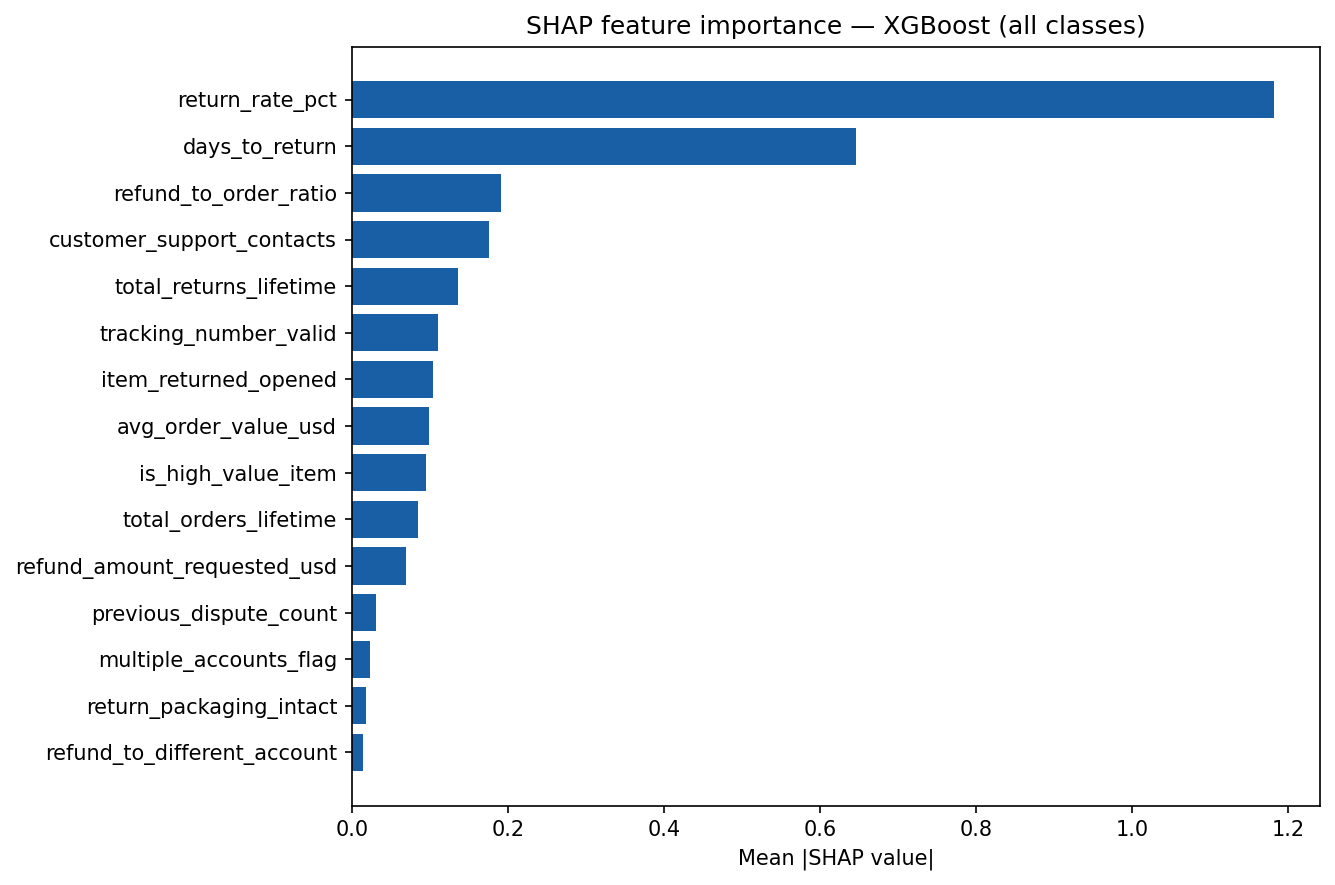


Top 10 features XGBoost:
                  feature  mean_abs_shap
          return_rate_pct       1.181318
           days_to_return       0.646482
    refund_to_order_ratio       0.190904
customer_support_contacts       0.175496
   total_returns_lifetime       0.136165
    tracking_number_valid       0.110341
     item_returned_opened       0.104558
      avg_order_value_usd       0.099186
       is_high_value_item       0.095679
    total_orders_lifetime       0.085026


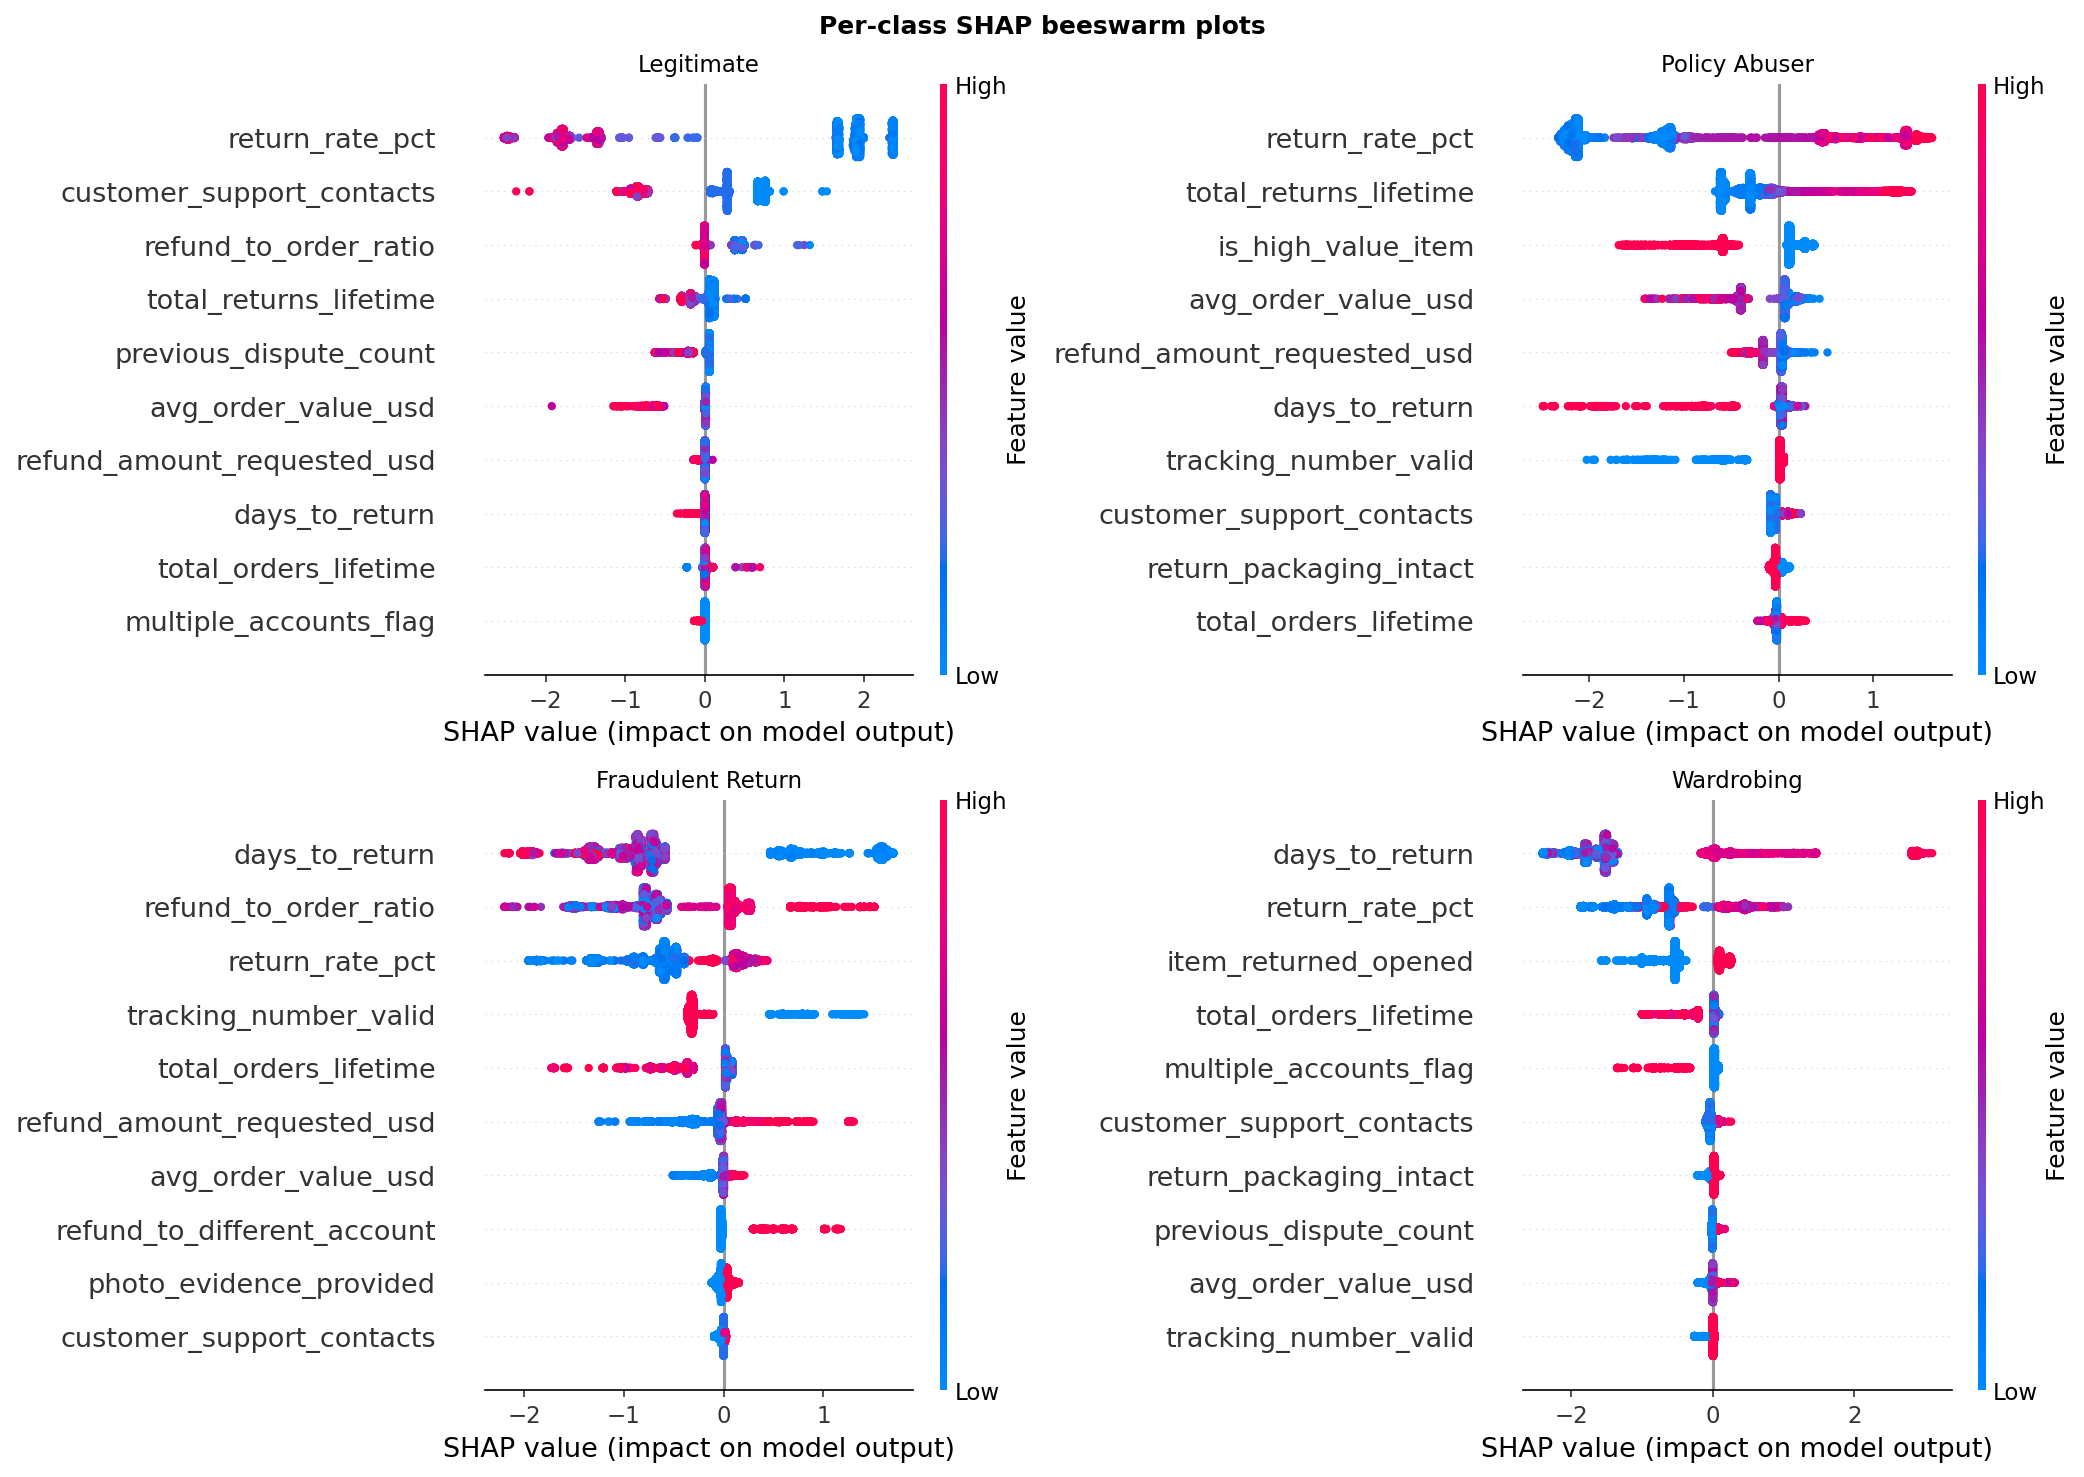

In [ ]:
# CELL 7a : SHAP - XGBoost
# ============================================================
explainer   = shap.TreeExplainer(xgb)

# Start timer
start_time_xgb = time.time()
shap_values = explainer.shap_values(X_te)
# End timer
end_time_xgb = time.time()
elapsed_time_xgb = end_time_xgb - start_time_xgb
print(f"XGBoost SHAP generation time: {elapsed_time_xgb:.4f} seconds")

# Check shape
print("shap_values type:", type(shap_values))
print("shap_values shape:", np.array(shap_values).shape)

# Handle both list and array formats
if isinstance(shap_values, list):
    shap_arr = np.stack(shap_values, axis=2)  # (n_samples, n_features, n_classes)
else:
    shap_arr = shap_values                     # already (n_samples, n_features, n_classes)

print("shap_arr shape:", shap_arr.shape)

# ── Global bar chart — mean |SHAP| across all classes ────────
mean_abs_shap = np.abs(shap_arr).mean(axis=(0, 2))  # (n_features,)
shap_df = (
    pd.DataFrame({"feature": FEATURE_NAMES, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(shap_df["feature"][::-1], shap_df["mean_abs_shap"][::-1], color="#185FA5")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("SHAP feature importance — XGBoost (all classes)")
plt.tight_layout()
plt.savefig("fig_shap_bar.png", dpi=150)
plt.show()

print("\nTop 10 features XGBoost:")
print(shap_df.head(10).to_string(index=False))

# ── Per-class beeswarm plots ──────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, (ax, cls_name) in enumerate(zip(axes.flat, CLASS_NAMES)):
    plt.sca(ax)
    shap.summary_plot(
        shap_arr[:, :, idx],
        X_te,
        show=False,
        plot_size=None,
        max_display=10
    )
    ax.set_title(cls_name, fontsize=11)
plt.suptitle("Per-class SHAP beeswarm plots", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_shap_per_class.png", dpi=150)
plt.show()

### SHAP — RANDOM FOREST

Random Forest SHAP generation time: 189.6964 seconds
shap_values type: <class 'numpy.ndarray'>
shap_values shape: (12000, 21, 4)
shap_arr shape: (12000, 21, 4)


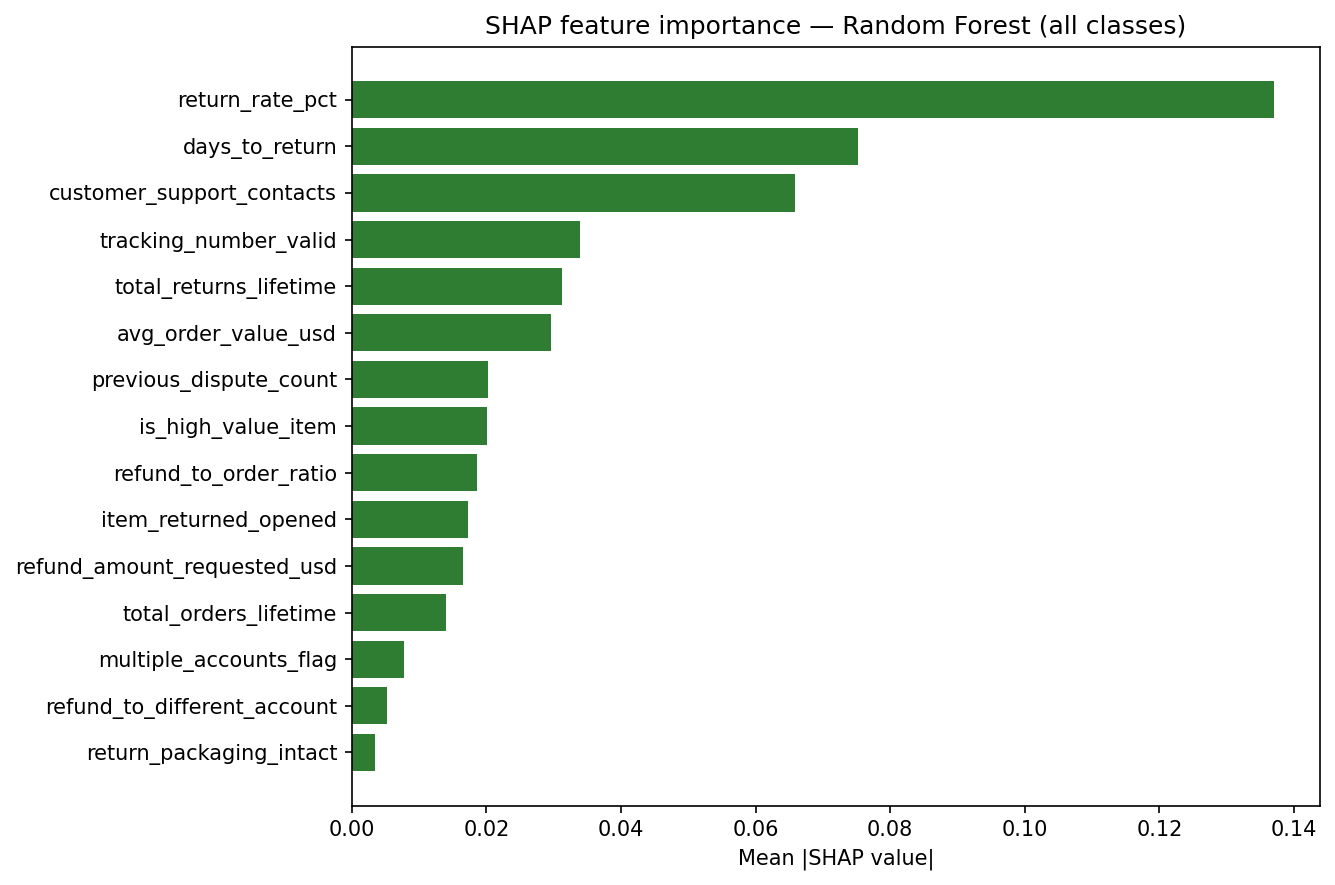


Top 10 features Random Forest:
                  feature  mean_abs_shap
          return_rate_pct       0.137006
           days_to_return       0.075150
customer_support_contacts       0.065815
    tracking_number_valid       0.033937
   total_returns_lifetime       0.031311
      avg_order_value_usd       0.029591
   previous_dispute_count       0.020197
       is_high_value_item       0.020128
    refund_to_order_ratio       0.018630
     item_returned_opened       0.017344


In [ ]:
# CELL 7b : SHAP — Random Forest
# ============================================================
explainer_rf   = shap.TreeExplainer(rf)

# Start timer
start_time_rf = time.time()
shap_values_rf = explainer_rf.shap_values(X_te)
# End timer
end_time_rf = time.time()
elapsed_time_rf = end_time_rf - start_time_rf
print(f"Random Forest SHAP generation time: {elapsed_time_rf:.4f} seconds")

# Check shape
print("shap_values type:", type(shap_values_rf))
print("shap_values shape:", np.array(shap_values_rf).shape)

# Handle both list and array formats
if isinstance(shap_values_rf, list):
    shap_arr_rf = np.stack(shap_values_rf, axis=2)  # (n_samples, n_features, n_classes)
else:
    shap_arr_rf = shap_values_rf                     # already (n_samples, n_features, n_classes)

print("shap_arr shape:", shap_arr_rf.shape)

# ── Global bar chart — mean |SHAP| across all classes
mean_abs_shap_rf = np.abs(shap_arr_rf).mean(axis=(0, 2))  # (n_features,)
shap_df_rf = (
    pd.DataFrame({"feature": FEATURE_NAMES, "mean_abs_shap": mean_abs_shap_rf})
    .sort_values("mean_abs_shap", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(shap_df_rf["feature"][::-1], shap_df_rf["mean_abs_shap"][::-1], color="#2E7D32")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("SHAP feature importance — Random Forest (all classes)")
plt.tight_layout()
plt.savefig("fig_shap_rf_bar.png", dpi=150)
plt.show()

print("\nTop 10 features Random Forest:")
print(shap_df_rf.head(10).to_string(index=False))

# **STAGE 4: CONCENSUS ROUTING + LOCAL SHAP + LLM ANALYST BRIEF**
# **GRADIO INTERFACE**

In [ ]:
print("Actual return_reason values in dataset:")
print(sorted(df['return_reason'].unique()))

print("\nActual customer_segment values:")
print(sorted(df['customer_segment'].unique()))

print("\nActual payment_method values:")
print(sorted(df['payment_method'].unique()))

Actual return_reason values in dataset:
['Accidental Order', 'Arrived Late', 'Changed Mind', 'Defective/Broken', 'Found Better Price', 'Gift Duplicate', 'Item Not Received', 'Not As Described', 'Quality Issue', 'Too Large', 'Too Small', 'Wrong Item Sent']

Actual customer_segment values:
['Bronze', 'Gold', 'New', 'Platinum', 'Silver']

Actual payment_method values:
['Buy Now Pay Later', 'Credit Card', 'Crypto', 'Debit Card', 'Gift Card', 'PayPal']


In [ ]:
# ============================================================
# CELL 8: GRADIO INTERFACE
#
# Consensus routing + LLM
#   Routing based on model agreement, not fixed threshold
#   Justification: disagreement between two independent
#   models is a genuine uncertainty signal that should
#   escalate to human review regardless of confidence
#
# Decision tiers:
#   ROUTINE PROCESSING  — both models agree = Legitimate
#   FLAG FOR REVIEW     — disagreement OR Policy Abuser
#   ESCALATE            — both agree = Fraudulent/Wardrobing
# ============================================================

def get_local_shap(X_input_df):
    """
    Compute local SHAP for a single transaction.
    Returns formatted string of top 3 risk factors.

    sv shape is (1, n_features, n_classes)
    Use sv_arr[0, :, pred_class] for per-class values.
    """
    pred_class = int(np.argmax(
        xgb.predict_proba(X_input_df)[0]))

    sv       = explainer.shap_values(X_input_df)
    sv_arr   = np.array(sv)         # (1, 21, 4)
    cls_shap = sv_arr[0, :, pred_class]  # (21,)

    top_idx = np.argsort(np.abs(cls_shap))[::-1][:3]

    lines = []
    for i in top_idx:
        direction = ("↑ increases risk"
                     if cls_shap[i] > 0
                     else "↓ decreases risk")
        lines.append(
            f"  • {FEATURE_NAMES[i]}: "
            f"{direction} "
            f"(SHAP = {cls_shap[i]:+.3f})")
    return "\n".join(lines)


def generate_brief(signals, pred_class,
                   conf, decision, shap_text):
    """
    Call Gemini API to generate SHAP-grounded analyst brief.
    LLM receives prediction + top 3 SHAP features.
    Brief is grounded in model reasoning, not just raw values.
    """
    prompt = f"""You are a fraud analyst assistant for an
e-commerce returns team. A return transaction has been
flagged by an AI detection system. Write a professional
case brief of 3-4 sentences for a human analyst.
Focus your explanation on the three model risk factors
listed below and explain what the analyst should verify.
Do not invent information beyond what is provided.

System decision: {decision}
Predicted abuse type: {pred_class} ({conf:.0%} confidence)

Top 3 model risk factors (SHAP analysis):
{shap_text}

Supporting transaction context:
- Return rate (lifetime): {signals['return_rate_pct']:.1f}%
- Lifetime returns: {signals['total_returns_lifetime']}
- Previous disputes: {signals['previous_dispute_count']}
- Support contacts: {signals['customer_support_contacts']}
- Refund requested: ${signals['refund_amount_requested_usd']:.2f}
- Refund/order ratio: {signals['refund_to_order_ratio']:.2f}x
- Days to return: {signals['days_to_return']}
- Item returned opened: {'Yes' if signals['item_returned_opened'] else 'No'}
- Packaging intact: {'Yes' if signals['return_packaging_intact'] else 'No'}
- Photo evidence provided: {'Yes' if signals['photo_evidence_provided'] else 'No'}
- Tracking number valid: {'Yes' if signals['tracking_number_valid'] else 'No'}
- Refund to different account: {'Yes' if signals['refund_to_different_account'] else 'No'}
"""
    try:
        client = genai.Client(api_key=GEMINI_API_KEY)
        response = client.models.generate_content(
        model='gemini-3.1-flash-lite',
        contents=prompt
        )
        return response.text
    except Exception as e:
        return f"LLM unavailable: {e}"


def analyse(
    return_rate, total_returns, total_orders,
    disputes, support, acct_age, segment, multi_accts,
    avg_order, refund_amt, payment, high_value,
    discount, diff_acct,
    days_return, opened, pkg_intact,
    photo, tracking, reason
):
    # ── Compute engineered feature ────────────────────────
    refund_ratio = (refund_amt / avg_order
                    if avg_order > 0 else 0)

    # ── Build signals dict ────────────────────────────────
    signals = {
        'return_rate_pct':            return_rate,
        'total_returns_lifetime':      total_returns,
        'total_orders_lifetime':       total_orders,
        'previous_dispute_count':      disputes,
        'customer_support_contacts':   support,
        'account_age_days':            acct_age,
        'customer_segment':
            le_dict['customer_segment']
            .transform([segment])[0],
        'multiple_accounts_flag':      int(multi_accts),
        'avg_order_value_usd':         avg_order,
        'refund_amount_requested_usd': refund_amt,
        'payment_method':
            le_dict['payment_method']
            .transform([payment])[0],
        'is_high_value_item':          int(high_value),
        'discount_used':               int(discount),
        'refund_to_different_account': int(diff_acct),
        'refund_to_order_ratio':       refund_ratio,
        'days_to_return':              days_return,
        'item_returned_opened':        int(opened),
        'return_packaging_intact':     int(pkg_intact),
        'photo_evidence_provided':     int(photo),
        'tracking_number_valid':       int(tracking),
        'return_reason':
            le_dict['return_reason']
            .transform([reason])[0],
    }

    # Build input DataFrame in correct feature order
    X_in = pd.DataFrame(
        [[signals[f] for f in FEATURE_NAMES]],
        columns=FEATURE_NAMES)

    # ── Stage 2: Classification ───────────────────────────
    xgb_prob   = xgb.predict_proba(X_in)[0]
    xgb_pred   = int(np.argmax(xgb_prob))
    xgb_conf   = xgb_prob.max()
    pred_class = INV_MAP[xgb_pred]

    rf_prob   = rf.predict_proba(X_in)[0]
    rf_pred   = int(np.argmax(rf_prob))
    rf_conf   = rf_prob.max()
    pred_class_rf = INV_MAP[rf_pred]

    rf_pred      = int(rf.predict(X_in)[0])
    models_agree = (xgb_pred == rf_pred)

    # ── Stage 3: Local SHAP explanation ──────────────────
    # Stage 3 — Local SHAP for each flagged transaction
    # Computes top 3 features driving this specific prediction
    # Passes SHAP output directly into LLM prompt
    # Only compute for non-legitimate predictions
    # to keep interface responsive
    shap_text = ""
    if xgb_pred != 0:
        shap_text = get_local_shap(X_in)

    # ── Stage 4: Consensus routing ────────────────────────
    # Routing logic:
    # 1. Models disagree → human review always
    # 2. Both agree Legitimate → routine processing
    # 3. Both agree Fraudulent/Wardrobing → escalate
    # 4. Both agree Policy Abuser → flag (needs conversation
    #    not refund block — different intervention required)

    if not models_agree:
        decision = "🟡 FLAG FOR REVIEW — model disagreement"
        tier     = "flag"

    elif xgb_pred == 0:
        decision = "🟢 ROUTINE PROCESSING"
        tier     = "routine"

    elif xgb_pred in [2, 3]:  # Fraudulent or Wardrobing
        decision = "🔴 ESCALATE — HOLD REFUND"
        tier     = "escalate"

    else:  # Policy Abuser
        decision = "🟡 FLAG FOR REVIEW — policy abuse detected"
        tier     = "flag"

    # ── Build result output ───────────────────────────────
    probs_text = "\n".join([
        f"  {CLASS_NAMES[i]:<22} {xgb_prob[i]*100:>5.1f}%"
        for i in range(4)])

    probs_text_rf = "\n".join([
        f"  {CLASS_NAMES[i]:<22} {rf_prob[i]*100:>5.1f}%"
        for i in range(4)])

    shap_display = (
        f"\nTop SHAP (XGBoost) risk factors:\n{shap_text}"
        if shap_text else "")

    result = (
        f"{'='*50}\n"
        f"  DECISION:  {decision}\n"
        f"{'='*50}\n"
        f"XGBoost Predicted type:  {pred_class}\n"
        f"Confidence:      {xgb_conf:.1%}\n\n"
        f"XGBoost Class probabilities:\n"
        f"{probs_text}\n\n"
        f"Random Forest Predicted type:  {pred_class_rf}\n"
        f"Confidence:      {rf_conf:.1%}\n\n"
        # f"Class probabilities (Random Forest):\n"
        # f"{probs_text_rf}\n\n"
        f"Model consensus: "
        f"{'✓ XGBoost + RF agree' if models_agree else '✗ Models disagree — routed to review'}"
        f"{shap_display}"
    )

    # ── Stage 4: LLM analyst brief ────────────────────────
    if tier == "routine":
        brief = (
            "No analyst action required.\n\n"
            f"Both XGBoost and Random Forest independently "
            f"classify this return as Legitimate "
            f"({xgb_conf:.0%} confidence).\n\n"
            "Customer retains full refund rights under the "
            "Consumer Guarantees Act 1993 (NZ). "
            "No further investigation warranted.")
    else:
        brief = generate_brief(
            signals, pred_class,
            xgb_conf, decision, shap_text)

    return result, brief


# ── Gradio layout ─────────────────────────────────────────────
with gr.Blocks(title="Return Abuse Detection System") as demo:

    gr.Markdown(
        "## 🛒 AI-Integrated System for E-Commerce Return Abuse Detection and Classification")
    gr.Markdown(
        "**Stage 1:** Preprocessing and Future Engineering |  "
        "**Stage 2:** XGBoost + Random Forest Classification |  "
        "**Stage 3:** Evaluation and Interpretability  |  "
        "**Stage 4:** Consensus Routing, Local SHAP, and LLM Analyst Brief")

    with gr.Row():

        # ── Left column — inputs ──────────────────────────
        with gr.Column():

            gr.Markdown("### 👤 Customer Behaviour")
            rt  = gr.Slider(0, 100, 15, step=0.1,
                            label="Return Rate % (lifetime)")
            tr  = gr.Number(3,
                            label="Total Returns (lifetime)")
            to_ = gr.Number(20,
                            label="Total Orders (lifetime)")
            di  = gr.Slider(0, 5, 0, step=1,
                            label="Previous Disputes")
            su  = gr.Slider(0, 6, 1, step=1,
                            label="Customer Support Contacts")
            aa  = gr.Number(365,
                            label="Account Age (days)")
            seg = gr.Dropdown(
                list(le_dict['customer_segment'].classes_),
                value='Silver',
                label="Customer Segment")
            ma  = gr.Checkbox(
                label="Multiple Accounts Flag")
            gr.Markdown("&nbsp;")
            btn = gr.Button(
                "🔍 Analyse Return",
                variant="primary",
                size="lg")

            gr.Markdown(
                "**Decision tiers:**\n\n"
                "🟢 **Routine** — both models confirm "
                "legitimate return\n\n"
                "🟡 **Flag** — model disagreement or "
                "policy abuse detected\n\n"
                "🔴 **Escalate** — both models confirm "
                "fraudulent return or wardrobing")

        # ── Right column — inputs + outputs ───────────────
        with gr.Column():

            gr.Markdown("### 📦 Return Patterns")
            dr  = gr.Slider(1, 55, 10, step=1,
                            label="Days to Return")
            io_ = gr.Checkbox(
                label="Item Returned Opened")
            pi  = gr.Checkbox(
                label="Packaging Intact")
            pe  = gr.Checkbox(
                label="Photo Evidence Provided")
            tv  = gr.Checkbox(
                value=True,
                label="Tracking Number Valid")
            rr  = gr.Dropdown(
                choices=list(le_dict['return_reason'].classes_),
                value='Changed Mind',
                label="Return Reason")

            gr.Markdown("### 💳 Transaction History")
            ao  = gr.Number(150.0,
                            label="Avg Order Value (USD)")
            ra  = gr.Number(120.0,
                            label="Refund Requested (USD)")
            pm  = gr.Dropdown(
                choices=list(le_dict['payment_method'].classes_),
                value='Credit Card',
                label="Payment Method")
            hv  = gr.Checkbox(label="High Value Item")
            dc  = gr.Checkbox(label="Discount Used")
            da  = gr.Checkbox(
                label="Refund to Different Account")

    with gr.Row():
        out_r = gr.Textbox(
            label="🤖 Detection Result",
            lines=20)
        out_b = gr.Textbox(
            label="📋 AI Analyst Brief (SHAP-grounded)",
            lines=20)

    btn.click(
        fn=analyse,
        inputs=[
            rt, tr, to_, di, su, aa, seg, ma,
            ao, ra, pm, hv, dc, da,
            dr, io_, pi, pe, tv, rr],
        outputs=[out_r, out_b])

    gr.Markdown(
        "---\n"
        "*MAIC01802 – AI for IT Professionals | "
        "Assessment 2*  \n"
        "An AI-Integrated System for E-Commerce Return Abuse Detection and Classification | "
        "Dataset: E-Commerce Return Abuse Detection "
        "(Kaggle, Sarvesh Chhetri, 2026)")

# ── Launch ────────────────────────────────────────────────────
# Run this cell on presentation morning
# share=True generates a public URL valid for 72 hours
# Copy the URL for your report submission
demo.launch(share=True)
# demo.launch(debug=True, show_error=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0d4588fe2de36a0224.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
